# **Projeto de Machine Learning**

## **APS1: Projeto EDA**

In [36]:
import pandas as pd 
import matplotlib.pyplot as plt

### 1. Carregamento e inspeção inicial dos dados:

In [37]:

with open("../data/adult.data", "r") as file:
    for i in range(5):
        print(file.readline())

39, State-gov, 77516, Bachelors, 13, Never-married, Adm-clerical, Not-in-family, White, Male, 2174, 0, 40, United-States, <=50K

50, Self-emp-not-inc, 83311, Bachelors, 13, Married-civ-spouse, Exec-managerial, Husband, White, Male, 0, 0, 13, United-States, <=50K

38, Private, 215646, HS-grad, 9, Divorced, Handlers-cleaners, Not-in-family, White, Male, 0, 0, 40, United-States, <=50K

53, Private, 234721, 11th, 7, Married-civ-spouse, Handlers-cleaners, Husband, Black, Male, 0, 0, 40, United-States, <=50K

28, Private, 338409, Bachelors, 13, Married-civ-spouse, Prof-specialty, Wife, Black, Female, 0, 0, 40, Cuba, <=50K



In [38]:
with open("../data/adult.names", "r") as file:
    for i, linha in enumerate(file):
        print(i, linha.strip())

0 | This data was extracted from the census bureau database found at
1 | http://www.census.gov/ftp/pub/DES/www/welcome.html
2 | Donor: Ronny Kohavi and Barry Becker,
3 |        Data Mining and Visualization
4 |        Silicon Graphics.
5 |        e-mail: ronnyk@sgi.com for questions.
6 | Split into train-test using MLC++ GenCVFiles (2/3, 1/3 random).
7 | 48842 instances, mix of continuous and discrete    (train=32561, test=16281)
8 | 45222 if instances with unknown values are removed (train=30162, test=15060)
9 | Duplicate or conflicting instances : 6
10 | Class probabilities for adult.all file
11 | Probability for the label '>50K'  : 23.93% / 24.78% (without unknowns)
12 | Probability for the label '<=50K' : 76.07% / 75.22% (without unknowns)
13 |
14 | Extraction was done by Barry Becker from the 1994 Census database.  A set of
15 |   reasonably clean records was extracted using the following conditions:
16 |   ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))
17 |
18 | Prediction t

Após uma análise dos arquivos "adult.data" e "adult.names" foi possível descobrir o nome das colunas em ordem para a estruturação do dataframe: 

**Variável Alvo (Target)**
---
`income`: Indica se a renda anual é maior ou menor que 50 mil dólares.

**Características Demográficas e Sociais**
---
* `age` Idade da pessoa em anos. (Contínua)

* `race` Raça declarada.(Categorias: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.)

* `sex` Sexo biológico. (Categorias: Female, Male.)

* `native-country` País de origem da pessoa. (Exemplos: United-States, Mexico, Philippines, Germany, etc. (Mais de 40 países).)

**Educação**
---
* `education` Nível educacional da pessoa. (Exemplos: Bachelors, Some-college, 11th, HS-grad, Masters, Doctorate, etc.)

* `education-num` Representação numérica do nível educacional. (contínua. Geralmente, quanto maior o número, maior o nível de escolaridade.)

**Vida Civil e Relacionamentos**
---
* `marital-status` Estado civil da pessoa. (Categorias: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, etc.)

* `relationship` Papel da pessoa na estrutura familiar. (Categorias: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.)


**Trabalho e Ocupação**
---
* `hours-per-week` Número de horas trabalhadas por semana. (Contínua)

* `workclass` Tipo de empregador ou setor de trabalho. (Categorias: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.)

* `occupation` Profissão ou ocupação da pessoa. (Categorias: Tech-support, Craft-repair, Exec-managerial, Prof-specialty, Sales, etc.)


**Variáveis Financeiras e Técnicas**
---
* `capital-gain` Ganhos de capital (Contínua. Lucro com venda de ativos).

* `capital-loss` Perdas de capital (Contínua. Prejuízos financeiros).

* `fnlwgt` Peso amostral atribuído pelo Census Bureau. (Explicação: É uma estimativa de quantas pessoas na população real aquele registro representa, baseada em características socio-demográficas semelhantes.)




In [39]:
colunas = ["age", "workclass", "fnlwgt", "education", 
           "education-num", "marital-status", "occupation",
           "relationship", "race", "sex", "capital-gain", 
           "capital-loss", "hours-per-week", "native-country", "income"]

df = pd.read_csv("../data/adult.data", names=colunas, sep=",")

for c in df.columns:
    if df[c].dtype == "str":
        df[c] = df[c].str.strip() 

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [41]:
rows_all_null = df.isna().all(axis=1).sum()
rows_some_null = df.isna().any(axis=1) & ~df.isna().all(axis=1)

print("Número de linhas com todas as features são nulas: ", rows_all_null.sum())
print("Número de linhas com algumas (não todas) features nulas: ", rows_some_null.sum())
print("\n")

#-----------------------------------------------------------------------------------------------------------------
print("Campos com valores ausentes do tipo: '?'")

for c in df.columns:
    qtd = (df[c] == "?").sum()
    if qtd > 0:
        print(f"{c}: {qtd}")

print("\n")

#------------------------------------------------------------------------------------------------------------------
info_df = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.values
})

num = [c for c in df.columns if df[c].dtype == "int64"]
cat = [c for c in df.columns if df[c].dtype == "str"]

print(f"Dados numéricos: {len(num)} -> {num}")
print(f"Dados categóricos: {len(cat)} -> {cat}")
print("\n")


#------------------------------------------------------------------------------------------------------------------
menor = len(df[df["income"] == "<=50K"])
maior = len(df[df["income"] == ">50K"])
print("Distribuição do target:")
print(f"income <= 50k: {menor} ({100*menor/(len(df)):.2f}%)")
print(f"income >50k: {maior} ({100*maior/(len(df)):.2f}%)")

Número de linhas com todas as features são nulas:  0
Número de linhas com algumas (não todas) features nulas:  0


Campos com valores ausentes do tipo: '?'
workclass: 1836
occupation: 1843
native-country: 583


Dados numéricos: 6 -> ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Dados categóricos: 9 -> ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


Distribuição do target:
income <= 50k: 24720 (75.92%)
income >50k: 7841 (24.08%)


### 2. Análise univariada

In [42]:

print(df[num].describe())


                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


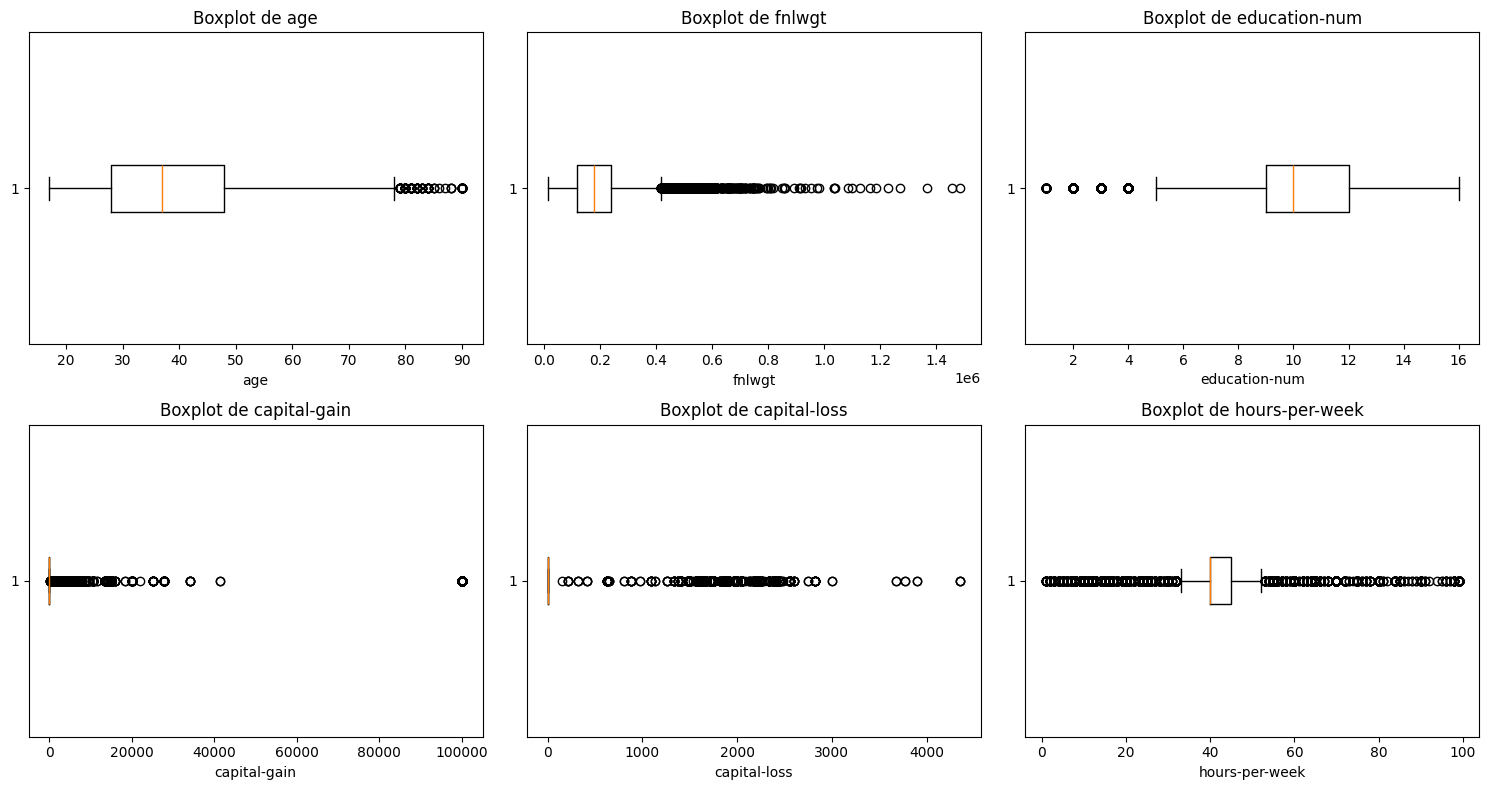

age: 143 outliers
fnlwgt: 992 outliers
education-num: 1198 outliers
capital-gain: 2712 outliers
capital-loss: 1519 outliers
hours-per-week: 9008 outliers


In [43]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, c in enumerate(num):
    axes[i].boxplot(df[c], vert=False)
    axes[i].set_title(f"Boxplot de {c}")
    axes[i].set_xlabel(c)

plt.tight_layout()
plt.show()


for c in num:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[c] < lower_bound) | (df[c] > upper_bound)]
    print(f"{c}: {len(outliers)} outliers")


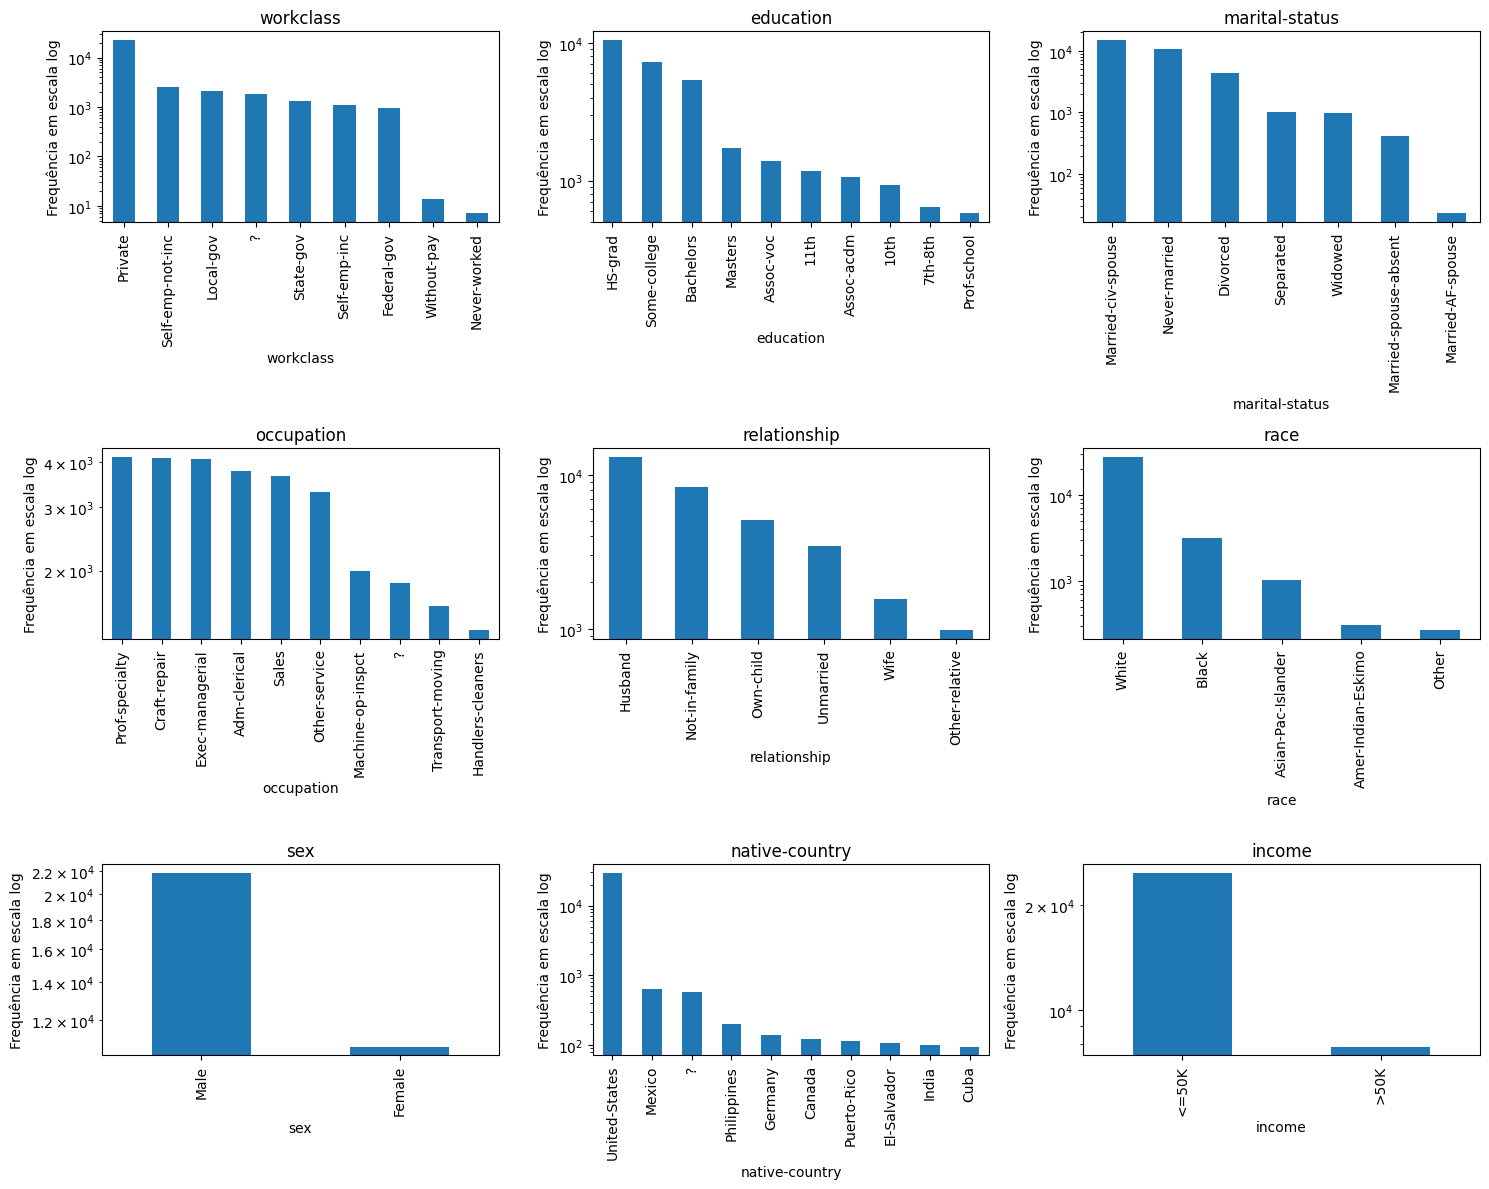

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
plt.title("Frquências em variáveis categóricas")

for i, col in enumerate(cat):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i], title=col, logy=True)
    axes[i].set_ylabel('Frequência em escala log')

plt.tight_layout()
plt.show()

In [45]:
print("hello world")

hello world


In [46]:
print("hello world 2")

hello world 2
